# REES46 네일 이커머스

RUNAIL 매출/이탈 구조, 경쟁 브랜드 유출 회수 가능성 확인

- 네일 시장 1위 RUNAIL과 2위 경쟁사 간 장바구니 중복 점유, 교차 이탈 흐름 추적
- 일반 고객과 대량 구매 패턴 분리, 가격 민감 구간($5~$7)과 최대 손실 지점($54,664) 확인
- 요일/시간대 번들링, 재구매 주기 단축, Lock-in 전략 기준 도출


## 데이터 로드

760만 건 네일 로그 기준
기간, 이벤트, 브랜드, 상품, 유저 규모 확인


In [1]:
# 실행 환경
import os
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')

# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
from operator import attrgetter

# 군집 분석
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 시각화 설정
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


C:\Users\ckcma\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# 데이터 로드
df = pd.read_csv('nail_market.csv')

# 시간대 기준
timezone = 'Etc/GMT-3'

# 시간 변수 정리
df['event_time'] = pd.to_datetime(df['event_time'], utc=True).dt.tz_convert(timezone)
df['event_time'] = df['event_time'].dt.tz_localize(None)
df['event_date'] = df['event_time'].dt.date
df['event_month'] = df['event_time'].dt.to_period('M')

# 기본 규모 확인
df_summary = pd.Series({
    'shape': df.shape,
    'start': df['event_time'].min(),
    'end': df['event_time'].max(),
    'event_type': df['event_type'].nunique(),
    'brand': df['brand'].nunique(),
    'product': df['product_id'].nunique(),
    'user': df['user_id'].nunique()
})
df_summary


shape                (7600542, 9)
start         2019-10-01 03:00:00
end           2020-03-01 02:59:59
event_type                      4
brand                          46
product                     18077
user                       657030
dtype: object

## 시장 현황

저가 소모품 중심 가격 구조
장바구니 이후 삭제/이탈이 큰 퍼널 구조


### 가격 구조

SKU, 브랜드, 유저 규모와 가격 분포 확인
$10 미만 상품 비중 86%대, 저가 반복 구매 시장 성격


price
0-5$       62.63%
5-10$      24.24%
10-20$      7.33%
20-50$      3.60%
50-100$     1.65%
100$+       0.56%
Name: proportion, dtype: str

중앙값 가격: $3.97


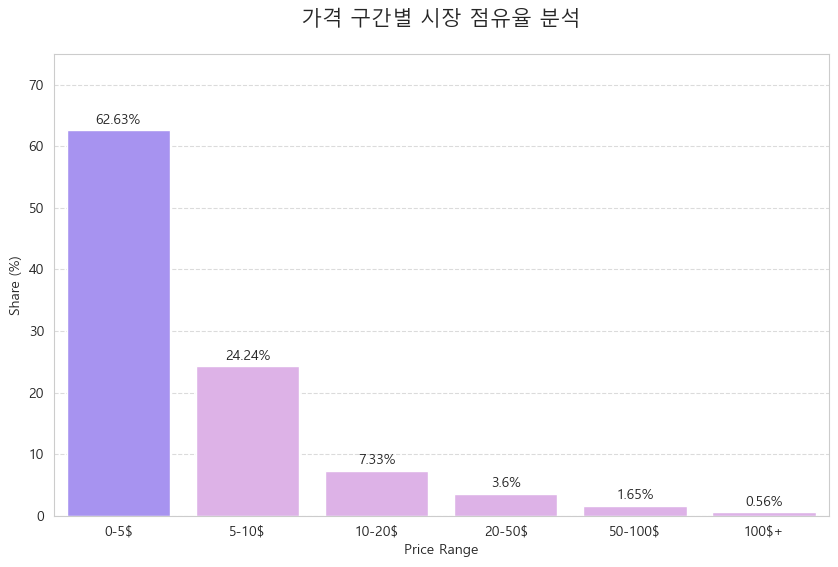

In [3]:
# 기본 고유값
df[['product_id', 'brand', 'user_id']].nunique()
df['price'].describe()

# 가격 구간 분포
price_bins = [0, 5, 10, 20, 50, 100, float('inf')]
price_labels = ['0-5$', '5-10$', '10-20$', '20-50$', '50-100$', '100$+']
price_segment = pd.cut(df['price'], bins= price_bins, labels=price_labels).value_counts(normalize=True).sort_index() * 100
display(price_segment.map('{:.2f}%'.format))
print(f"중앙값 가격: ${df['price'].median():.2f}")

# 시각화용 비중 테이블
data = {
    'Price Range': ['0-5$', '5-10$', '10-20$', '20-50$', '50-100$', '100$+'],
    'Proportion': [62.63, 24.24, 7.33, 3.60, 1.65, 0.56]
}
df_plot = pd.DataFrame(data)

# 가격대 비중 시각화
plt.figure(figsize=(10, 6))
colors = ['#9E84FF' if x > 30 else '#E2A9F0' for x in df_plot['Proportion']]
sns.barplot(data=df_plot, x='Price Range', y='Proportion', palette=colors)

for i, pct in enumerate(df_plot['Proportion']):
    plt.text(i, pct + 1, f'{pct}%', ha='center')

plt.title('가격 구간별 시장 점유율 분석', fontsize=15, pad=20)
plt.ylabel('Share (%)')
plt.ylim(0, 75)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### 퍼널

view-cart-purchase 유저 흐름 확인
장바구니 이후 삭제율 높음, 구매 전환 전 이탈 집중


event_type
view                44.1
cart                28.6
remove_from_cart    20.9
purchase             6.3
Name: proportion, dtype: float64

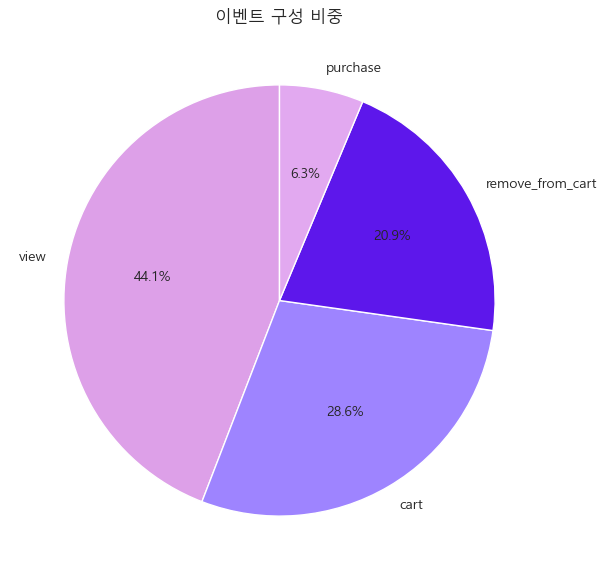

,stage,user_count,retention_rate,total_conversion_rate
0,view,616100,100.000000,100.000000
1,cart,218878,35.526376,35.526376
2,purchase,72524,33.134440,11.771466



장바구니 담기 대비 삭제율: 73.12%


In [4]:
# 이벤트 비중
event_share = (
    df['event_type']
    .value_counts(normalize=True)
    .reindex(['view', 'cart', 'remove_from_cart', 'purchase'])
    .mul(100)
    .round(1)
)
display(event_share)

# 이벤트 구성 시각화
plt.figure(figsize=(7, 7))
plt.pie(
    event_share,
    labels=event_share.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#DDA0E8', '#9E84FF', '#5D17EB', '#E2A9F0']
)
plt.title('이벤트 구성 비중')
plt.show()

# 유저 퍼널
funnel = df.groupby('event_type')['user_id'].nunique().reindex(['view', 'cart', 'purchase'])
funnel_df = pd.DataFrame({'stage': funnel.index, 'user_count': funnel.values})
funnel_df['retention_rate'] = funnel_df['user_count'].pct_change().add(1).fillna(1) * 100
funnel_df['total_conversion_rate'] = (funnel_df['user_count'] / funnel_df.iloc[0]['user_count']) * 100
display(funnel_df)

# 퍼널 시각화
fig = px.funnel(funnel_df, x='user_count', y='stage', title='전체 커머스 퍼널 분석')
fig.show()

# 장바구니 삭제율
event_counts = df['event_type'].value_counts()
cart_remove_rate = (event_counts.get('remove_from_cart', 0) / event_counts.get('cart', 1)) * 100
print(f'\n장바구니 담기 대비 삭제율: {cart_remove_rate:.2f}%')

### 장바구니 비교 행동

장바구니 상품 수별 전환율/삭제율 확인
다품목 비교 구간에서 전환과 이탈이 동시에 확대


,cart_segment,conversion_rate,remove_rate
0,1-2,16.82,30.95
1,3-5,35.79,48.05
2,6-10,45.32,57.62
3,11-20,53.79,66.62
4,21+,66.77,84.50


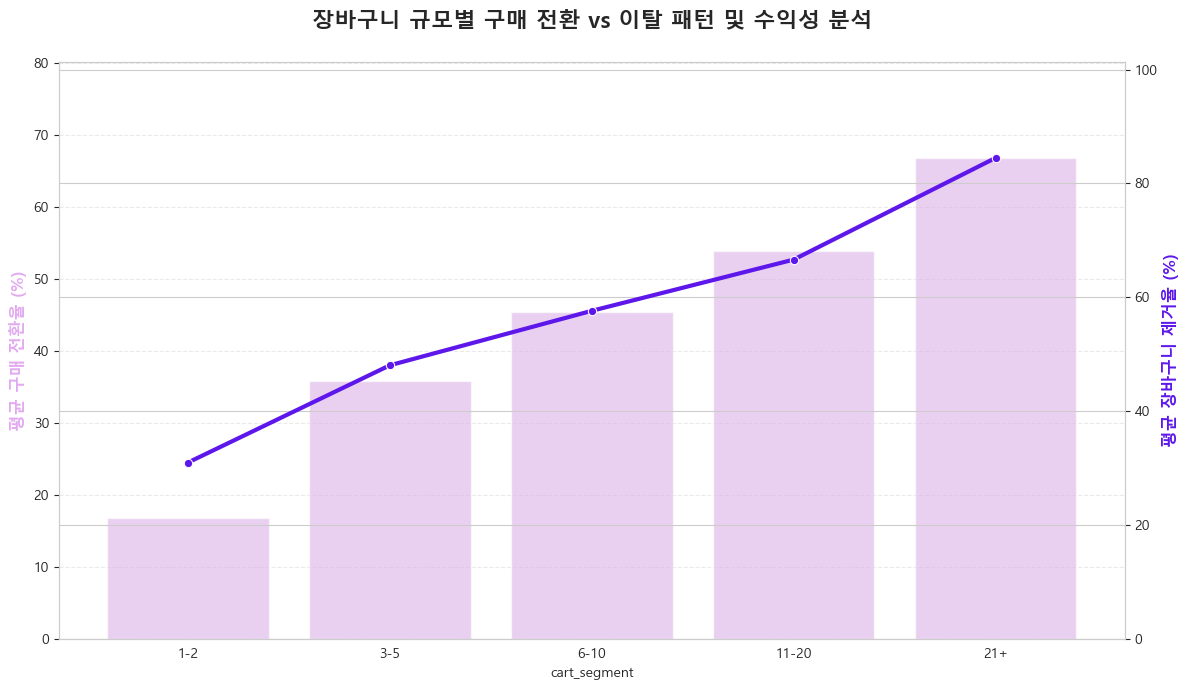

In [5]:
# 장바구니 구간
cart_bins = [0, 2, 5, 10, 20, np.inf]
cart_labels = ['1-2', '3-5', '6-10', '11-20', '21+']

# 유저별 이벤트 집계
user_events = df.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)

# 장바구니 상품 수
cart_items = df[df['event_type'] == 'cart'].groupby('user_id')['product_id'].nunique()
user_events['unique_cart_items'] = cart_items

# 장바구니 유저 분석셋
cart_user = user_events[user_events['unique_cart_items'] > 0].copy()
cart_user['remove_rate'] = cart_user['remove_from_cart'] / cart_user['cart']
cart_user['is_purchased'] = (cart_user['purchase'] > 0).astype(int)
cart_user['cart_segment'] = pd.cut(cart_user['unique_cart_items'],
                                  bins=cart_bins, labels=cart_labels)

# 구매 매출 연결
purchase_df = df[df['event_type'] == 'purchase'].copy()
user_revenue = purchase_df.groupby('user_id')['price'].sum()
cart_user['total_revenue'] = user_revenue.reindex(cart_user.index, fill_value=0)

# 구간별 전환·삭제율
seg = cart_user.groupby('cart_segment', observed=True).agg(
    conversion_rate=('is_purchased', 'mean'),
    remove_rate=('remove_rate', 'mean')
).reset_index()
seg[['conversion_rate', 'remove_rate']] *= 100

seg_rate = seg.copy()
seg_rate[['conversion_rate', 'remove_rate']] = seg_rate[['conversion_rate', 'remove_rate']].round(2)
display(seg_rate)

# 전환·이탈 시각화
fig, ax1 = plt.subplots(figsize=(12, 7))
sns.barplot(data=seg, x='cart_segment', y='conversion_rate',
            color='#E2A9F0', alpha=0.6, ax=ax1)
ax1.set_ylabel('평균 구매 전환율 (%)', fontsize=12, fontweight='bold', color='#E2A9F0')
ax1.set_ylim(0, seg['conversion_rate'].max() * 1.2)

ax2 = ax1.twinx()
sns.lineplot(data=seg, x='cart_segment', y='remove_rate',
             color='#5D17EB', marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('평균 장바구니 제거율 (%)', fontsize=12, fontweight='bold', color='#5D17EB')
ax2.set_ylim(0, seg['remove_rate'].max() * 1.2)

plt.title('장바구니 규모별 구매 전환 vs 이탈 패턴 및 수익성 분석', fontsize=16, pad=25, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

,cart_segment,total_revenue
0,1-2,11.430108
1,3-5,16.077571
2,6-10,23.438606
3,11-20,35.012483
4,21+,74.213424


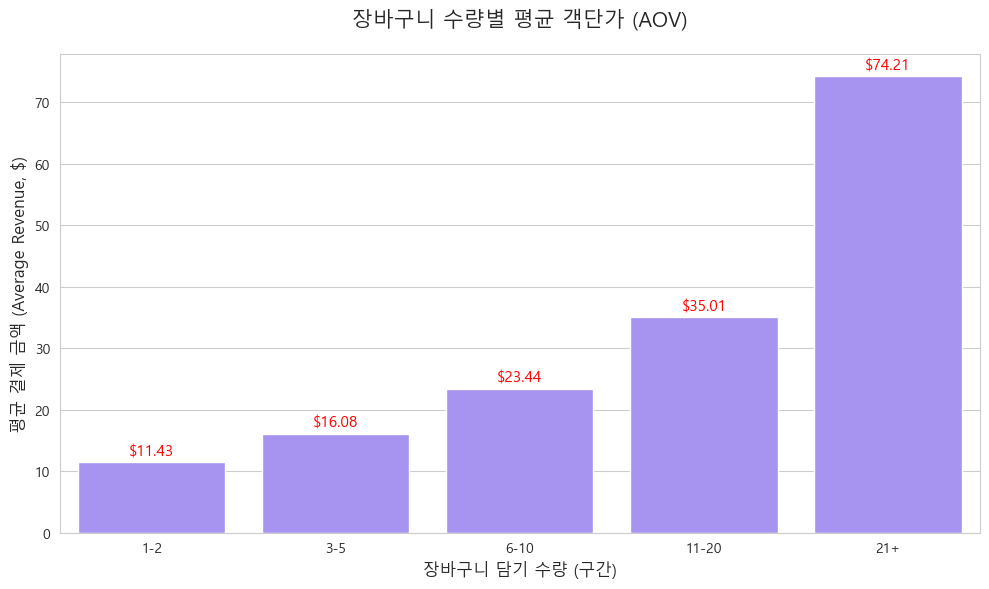

In [6]:
# 유저별 이벤트 집계
aov_events = df.groupby(['user_id', 'event_type']).size().unstack(fill_value=0)
aov_cart = df[df['event_type'] == 'cart'].groupby('user_id')['product_id'].nunique()
aov_events['unique_cart_items'] = aov_cart.reindex(aov_events.index, fill_value=0)

# 유저별 결제금액
aov_rev = purchase_df.groupby('user_id')['price'].sum().reset_index()
aov_rev.columns = ['user_id', 'total_revenue']

aov_df = pd.merge(aov_events.reset_index(), aov_rev, on='user_id', how='left')
aov_df['total_revenue'] = aov_df['total_revenue'].fillna(0)
aov_df['cart_segment'] = pd.cut(aov_df['unique_cart_items'],
                                bins=cart_bins, labels=cart_labels)

# 장바구니 구간별 AOV
aov_seg = (
    aov_df[aov_df['purchase'] > 0]
    .groupby('cart_segment', observed=True)['total_revenue']
    .mean()
    .reset_index()
)

display(aov_seg)

# AOV 시각화
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=aov_seg, x='cart_segment', y='total_revenue', color='#9E84FF')

plt.title('장바구니 수량별 평균 객단가 (AOV)', fontsize=15, pad=20)
plt.xlabel('장바구니 담기 수량 (구간)', fontsize=12)
plt.ylabel('평균 결제 금액 (Average Revenue, $)', fontsize=12)

for p in ax.patches:
    ax.annotate(f'${p.get_height():.2f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='red',
                xytext=(0, 8), textcoords='offset points')

plt.tight_layout()
plt.show()

### 구매 시점

요일/시간대별 탐색·구매 집중 구간 확인
평일 낮 활동 중심, 번들 노출 시간대 기준


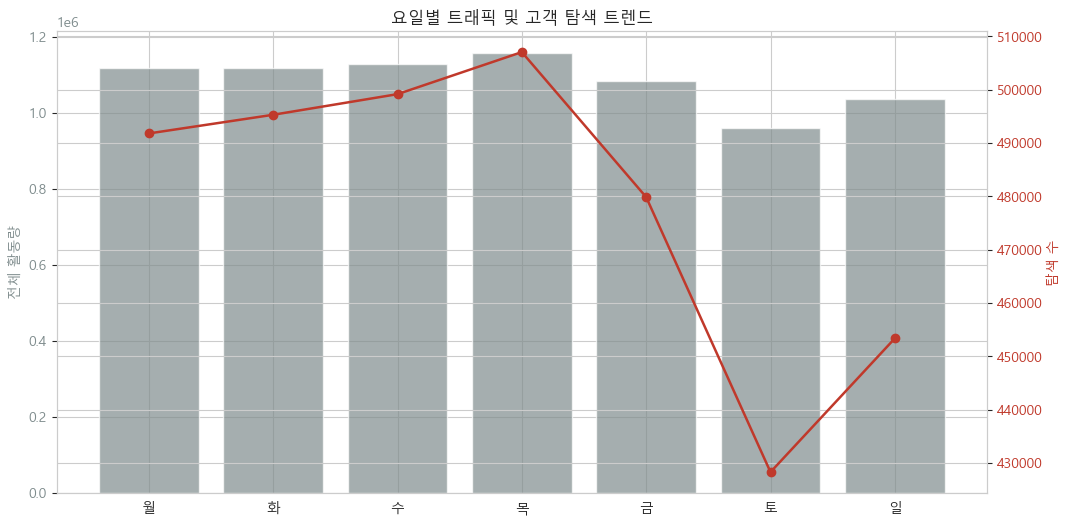

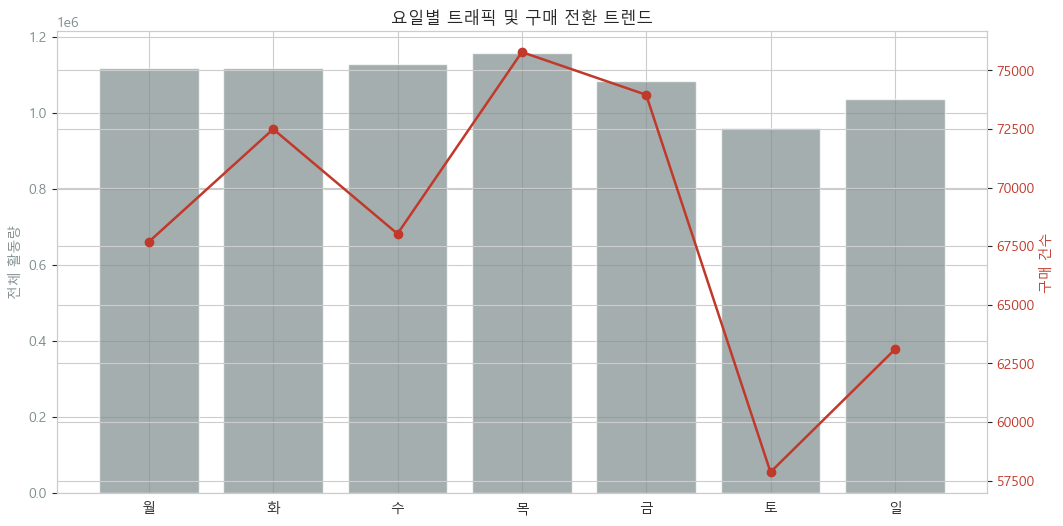

In [7]:
# 요일 변수
df['weekday'] = df['event_time'].dt.weekday
weekday_map = {0:'월', 1:'화', 2:'수', 3:'목', 4:'금', 5:'토', 6:'일'}
df['weekday_name'] = df['weekday'].map(weekday_map)
weekday_order = ['월', '화', '수', '목', '금', '토', '일']

# 요일별 이벤트 집계
event_by_day = df.groupby(['weekday_name', 'event_type']).size().unstack().reindex(weekday_order)

day_summary = pd.DataFrame({
    'weekday': weekday_order,
    'total': event_by_day.sum(axis=1).values,
    'view': event_by_day['view'].values,
    'purchase': event_by_day['purchase'].values
})

# 요일별 탐색 추세
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(day_summary['weekday'], day_summary['total'],
        color='#7F8C8D', alpha=0.7)
ax1.set_ylabel('전체 활동량', color='#7F8C8D')
ax1.tick_params(axis='y', labelcolor='#7F8C8D')

ax2 = ax1.twinx()
ax2.plot(day_summary['weekday'], day_summary['view'],
         color='#C0392B', marker='o', linewidth=1.8)
ax2.set_ylabel('탐색 수', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')

plt.title('요일별 트래픽 및 고객 탐색 트렌드')
plt.xticks(rotation=0)
plt.show()

# 요일별 구매 추세
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(day_summary['weekday'], day_summary['total'],
        color='#7F8C8D', alpha=0.7)
ax1.set_ylabel('전체 활동량', color='#7F8C8D')
ax1.tick_params(axis='y', labelcolor='#7F8C8D')

ax2 = ax1.twinx()
ax2.plot(day_summary['weekday'], day_summary['purchase'],
         color='#C0392B', marker='o', linewidth=1.8)
ax2.set_ylabel('구매 건수', color='#C0392B')
ax2.tick_params(axis='y', labelcolor='#C0392B')

plt.title('요일별 트래픽 및 구매 전환 트렌드')
plt.xticks(rotation=0)
plt.show()


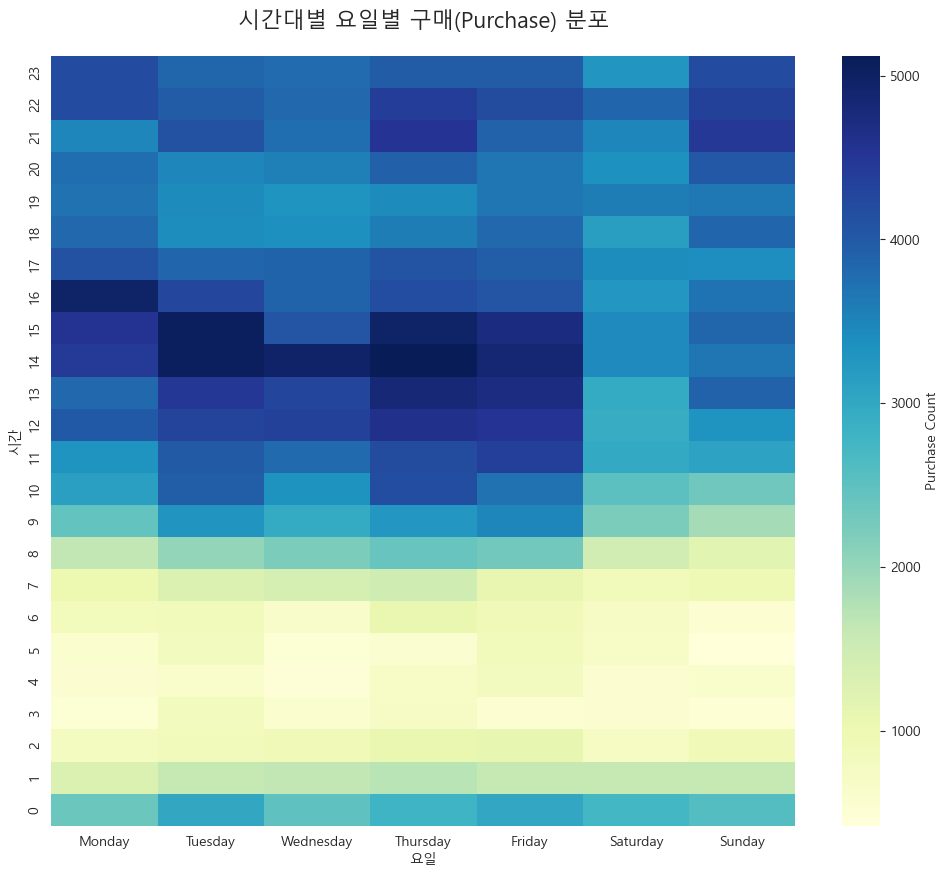

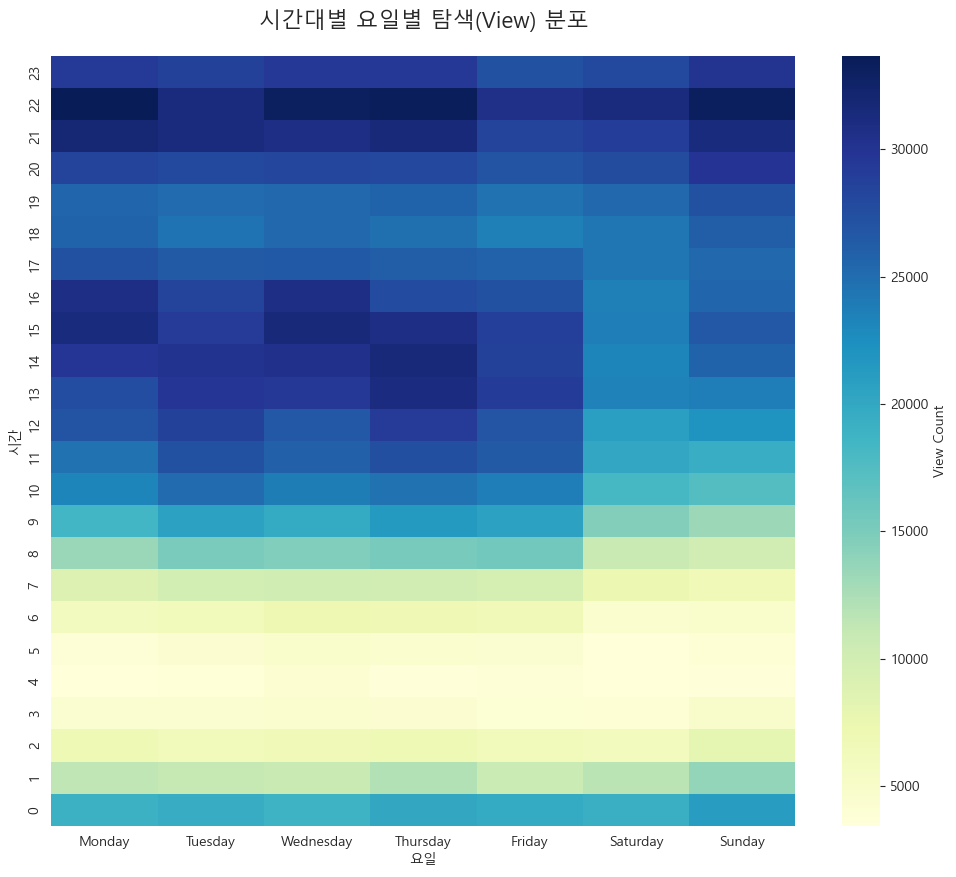

In [8]:
# 시간·요일 변수
df['hour'] = df['event_time'].dt.hour
weekday_en = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['weekday_en'] = df['event_time'].dt.day_name()

# 이벤트별 시간 히트맵
for event, title_suffix, cmap_label in [
    ('purchase', '구매(Purchase)', 'Purchase Count'),
    ('view', '탐색(View)', 'View Count')
]:
    # 시간대별 이벤트 수
    heatmap_data = df[df['event_type'] == event].pivot_table(
        index='hour', columns='weekday_en', values='user_id', aggfunc='count'
    )[weekday_en].iloc[::-1]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False,
                cbar_kws={'label': cmap_label})
    plt.title(f'시간대별 요일별 {title_suffix} 분포', fontsize=16, pad=20)
    plt.xlabel('요일')
    plt.ylabel('시간')
    plt.show()

## 구매 패턴

신규/기존 매출, 헤비유저, 재구매 간격 확인
기존 고객과 대량 구매 유저의 매출 기여도 확대


### 신규/기존 매출

월별 신규·기존 고객 매출 비중 확인
기존 고객 비중 증가, 재구매 관리 필요성 확인


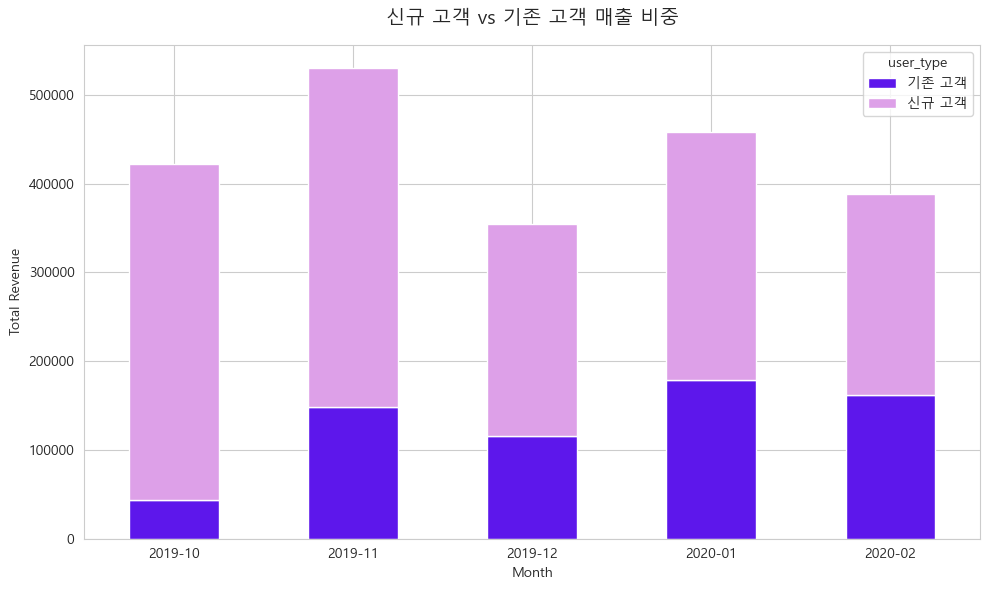

user_type,기존 고객,신규 고객
event_time,,
2019-10,10.24,89.76
2019-11,27.96,72.04
2019-12,32.63,67.37
2020-01,39.00,61.00
2020-02,41.70,58.30


In [9]:
# 구매 로그
purchase_df = df[(df['event_type'] == 'purchase') & (df['event_time'] < '2020-03-01')].copy()
purchase_df = purchase_df.sort_values('event_time')
purchase_df['event_date'] = purchase_df['event_time'].dt.date
purchase_df['first_purchase_date'] = purchase_df.groupby('user_id')['event_date'].transform('min')

# 신규/기존 구분
purchase_df['user_type'] = np.where(
    purchase_df['event_date'] == purchase_df['first_purchase_date'], '신규 고객', '기존 고객'
)

# 월별 매출
monthly_rev = purchase_df.groupby(
    [purchase_df['event_time'].dt.to_period('M'), 'user_type']
)['price'].sum().unstack()

monthly_rev = monthly_rev[['기존 고객', '신규 고객']]
# 매출 비중 시각화
ax = monthly_rev.plot(kind='bar', stacked=True,
                       color=['#5D17EB', '#DDA0E8'], figsize=(10, 6))
plt.title('신규 고객 vs 기존 고객 매출 비중', fontsize=14, pad=15)
plt.ylabel('Total Revenue')
plt.xlabel('Month')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

display((monthly_rev.div(monthly_rev.sum(axis=1), axis=0) * 100).round(2))

### 헤비유저

결제 세션 평균 4.6개, 최대 185개 상품 포함
상위 25% 기준 6개 이상 구매, 매출 비중 68.46%


In [10]:
# 구매 로그
purchase_df = df[df['event_type'] == 'purchase'].copy()
purchase_df = purchase_df.sort_values(['user_id', 'event_time'])
purchase_df['time_gap'] = purchase_df.groupby('user_id')['event_time'].diff()

# 결제 세션 기준
new_session = purchase_df['time_gap'].isna() | (purchase_df['time_gap'] > pd.Timedelta(minutes=30))
purchase_df['custom_session_id'] = new_session.groupby(purchase_df['user_id']).cumsum()

# 세션별 구매 상품 수
basket_sess = purchase_df.groupby(['user_id', 'custom_session_id'])['product_id'].nunique().reset_index()
basket_sess.columns = ['user_id', 'session_id', 'unique_item_count']

# 구매 상품 수 분포
basket_stat = basket_sess['unique_item_count'].describe(percentiles=[.25, .5, .75])
display(basket_stat)

heavy_min = int(basket_stat['75%'])
heavy_min

count    103568.000000
mean          4.588454
std           5.418881
min           1.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         185.000000
Name: unique_item_count, dtype: float64

6

In [11]:
# 유저별 구매 상품 수
basket = purchase_df.groupby('user_id')['product_id'].nunique()
heavy_users = set(basket[basket >= heavy_min].index)
heavy_user_pct = len(heavy_users) / basket.shape[0] * 100

# 헤비유저 매출 기여
total_rev = purchase_df['price'].sum()
heavy_rev = purchase_df[purchase_df['user_id'].isin(heavy_users)]['price'].sum()
heavy_share = (heavy_rev / total_rev) * 100

print(f'결제 세션 평균 구매 종류: {basket_stat["mean"]:.1f}개')
print(f'1회 최대 구매 종류: {int(basket_stat["max"]):,}개')
print(f'상위 25% 고객 기준: {heavy_min}개 이상 구매')
print(f'전체 매출: {total_rev:,.2f}')
print(f'헤비유저 매출: {heavy_rev:,.2f}')
print(f'헤비유저 매출 비중: {heavy_share:.2f}%')

결제 세션 평균 구매 종류: 4.6개
1회 최대 구매 종류: 185개
상위 25% 고객 기준: 6개 이상 구매
전체 매출: 2,154,477.97
헤비유저 매출: 1,474,912.58
헤비유저 매출 비중: 68.46%


### 재구매 간격

유저 단위와 동일상품 단위 재구매 주기 확인
유저 중앙 28일, 동일상품 중앙 8일로 반복 구매 주기 차이 확인


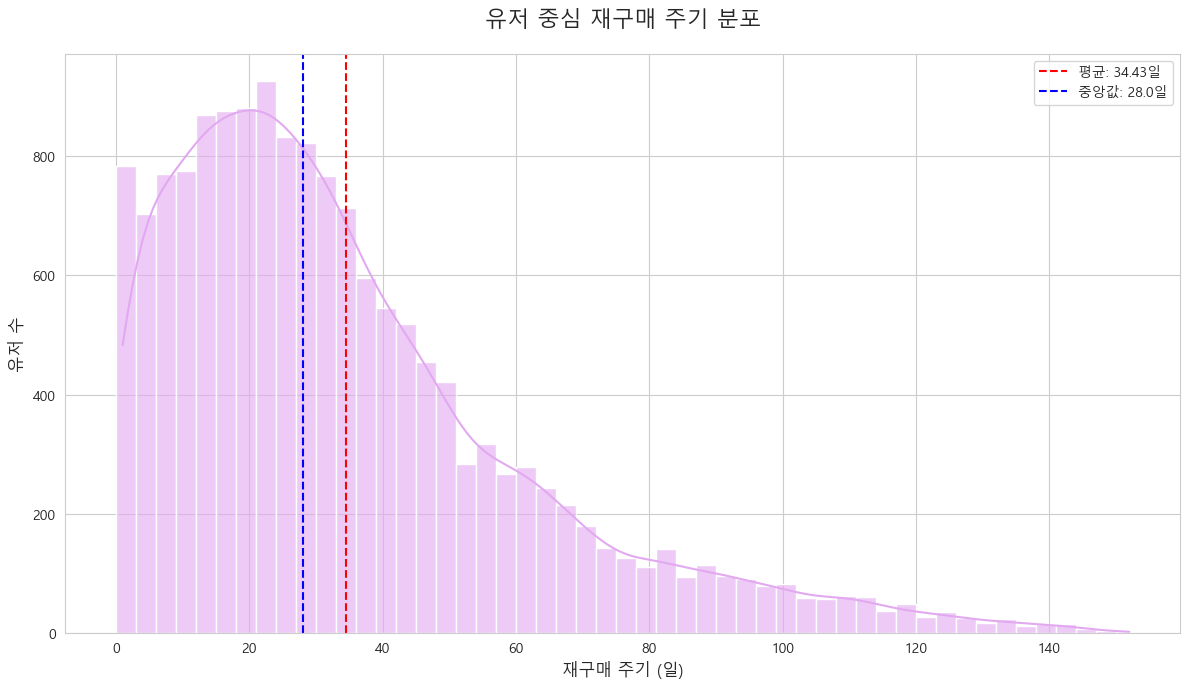

15607
34.43464184810144
28.0


In [12]:
# 구매 간격 함수
def calculate_intervals(dates):
    if len(dates) < 2:
        return None

    dates = sorted(dates)
    intervals = [(dates[i] - dates[i-1]).days for i in range(1, len(dates))]
    return intervals

# 구매 로그 정렬
purchase_df = df[df['event_type'] == 'purchase'].copy().sort_values(['user_id', 'event_time'])
# 유저별 구매일
user_dates = purchase_df.groupby('user_id')['event_time'].apply(
    lambda x: x.dt.date.unique()
).reset_index()

# 재구매 간격
user_dates['intervals'] = user_dates['event_time'].apply(calculate_intervals)
re_purchasers = user_dates.dropna(subset=['intervals']).copy()
re_purchasers['avg_interval'] = re_purchasers['intervals'].apply(lambda x: sum(x) / len(x))

mean_val = re_purchasers['avg_interval'].mean()
median_val = re_purchasers['avg_interval'].median()

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

# 재구매 주기 분포
plt.figure(figsize=(12, 7))
sns.histplot(re_purchasers['avg_interval'], binrange=(0, 150), bins=50,
             kde=True, color='#E2A9F0', edgecolor='white', alpha=0.6)
plt.axvline(mean_val, color='red', linestyle='--', label=f'평균: {mean_val:.2f}일')
plt.axvline(median_val, color='blue', linestyle='--', label=f'중앙값: {median_val:.1f}일')
plt.title('유저 중심 재구매 주기 분포', fontsize=16, pad=20)
plt.xlabel('재구매 주기 (일)', fontsize=12)
plt.ylabel('유저 수', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(len(re_purchasers))
print(mean_val)
print(median_val)

count    22594.000000
mean        23.645658
std         31.446553
min          0.000000
25%          0.000000
50%          8.000000
75%         39.000000
max        151.000000
Name: days_to_reorder, dtype: float64

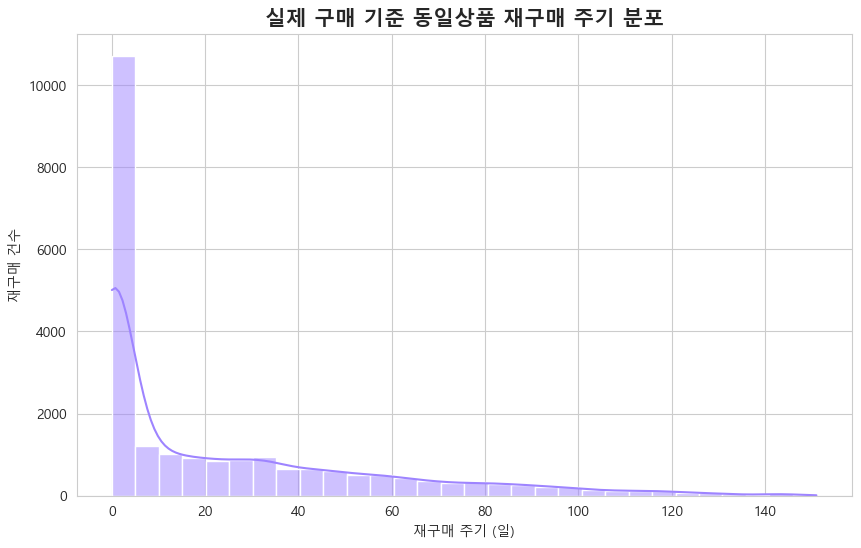

In [13]:
# 동일상품 구매 순서
reorder = purchase_df.sort_values(['user_id', 'product_id', 'event_time']).copy()
reorder['prev_time'] = reorder.groupby(['user_id', 'product_id'])['event_time'].shift(1)
reorder['days_to_reorder'] = (reorder['event_time'] - reorder['prev_time']).dt.days
# 동일상품 재구매 간격
reorder_stats = reorder.dropna(subset=['days_to_reorder'])

display(reorder_stats['days_to_reorder'].describe())

# 동일상품 재구매 분포
plt.figure(figsize=(10, 6))
sns.histplot(reorder_stats['days_to_reorder'], bins=30, kde=True, color='#9E84FF')
plt.title('실제 구매 기준 동일상품 재구매 주기 분포', fontsize=15, fontweight='bold')
plt.xlabel('재구매 주기 (일)')
plt.ylabel('재구매 건수')
plt.show()

### 리텐션

첫 구매 월 기준 재구매 유지율 확인
Heavy 그룹 유지율 우위, 일반 고객 대비 재방문 안정성 높음


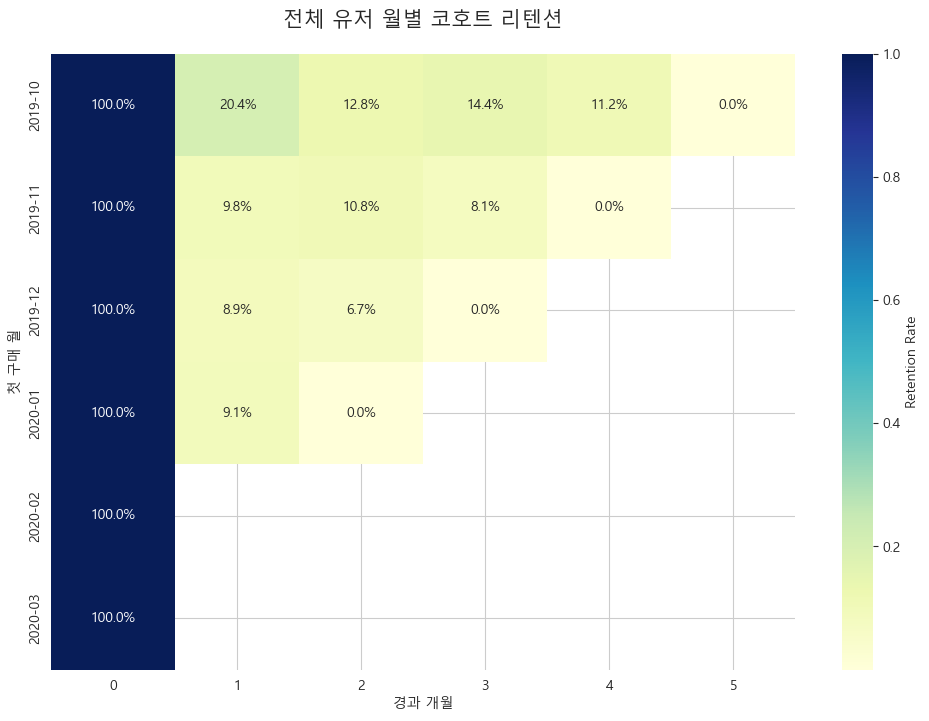

In [14]:
# 구매 코호트
cohort_df = df[df['event_type'] == 'purchase'].copy()
cohort_df['order_month'] = cohort_df['event_time'].dt.to_period('M')
cohort_df['first_month'] = cohort_df.groupby('user_id')['order_month'].transform('min')

# 월별 재구매 유저
cohort_counts = (
    cohort_df
    .groupby(['first_month', 'order_month'])['user_id']
    .nunique()
    .reset_index(name='n_customers')
)

cohort_counts['period'] = (cohort_counts['order_month'] - cohort_counts['first_month']).apply(attrgetter('n'))

# 리텐션 매트릭스
retention_pivot = cohort_counts.pivot_table(index='first_month', columns='period', values='n_customers')
retention_matrix = retention_pivot.divide(retention_pivot.iloc[:, 0], axis=0)

# 코호트 히트맵
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1%', cmap='YlGnBu',
            cbar_kws={'label': 'Retention Rate'})
plt.title('전체 유저 월별 코호트 리텐션', fontsize=15, pad=20)
plt.ylabel('첫 구매 월')
plt.xlabel('경과 개월')
plt.show()

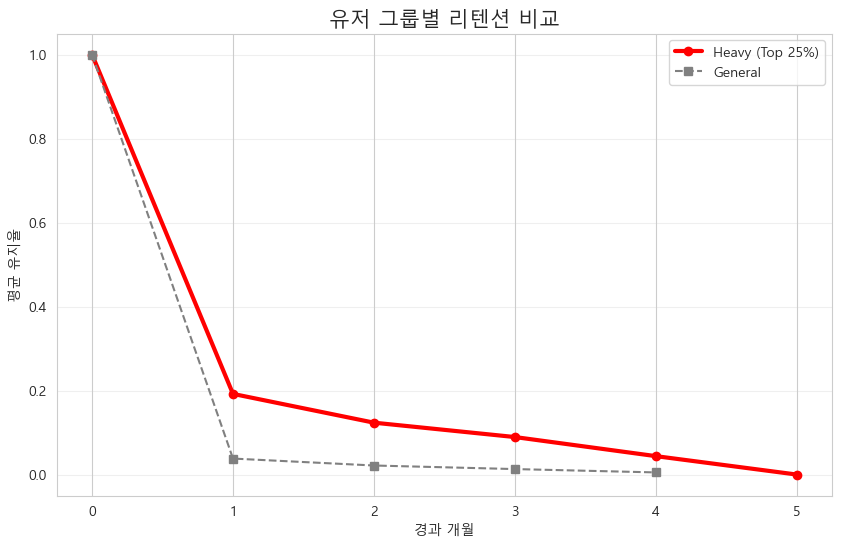

In [15]:
# 구매 로그
purchase_df = df[df['event_type'] == 'purchase'].copy()

# 헤비/일반 기준
user_rev = purchase_df.groupby('user_id')['price'].sum()
threshold = user_rev.quantile(0.75)
heavy_set = set(user_rev[user_rev >= threshold].index)

# 리텐션 분석 데이터셋
df_p = purchase_df.copy()
df_p['is_heavy'] = np.where(df_p['user_id'].isin(heavy_set), 'Heavy', 'General')
df_p['order_month'] = df_p['event_time'].dt.to_period('M')
df_p['first_month'] = df_p.groupby('user_id')['order_month'].transform('min')
df_p['period'] = (df_p['order_month'] - df_p['first_month']).apply(attrgetter('n'))

heavy_df = df_p[df_p['is_heavy'] == 'Heavy']
general_df = df_p[df_p['is_heavy'] == 'General']

# 그룹별 리텐션
heavy_counts = heavy_df.groupby(['first_month', 'period'])['user_id'].nunique().unstack(fill_value=0)
general_counts = general_df.groupby(['first_month', 'period'])['user_id'].nunique().unstack(fill_value=0)

heavy_ret = heavy_counts.divide(heavy_counts.iloc[:, 0], axis=0).mean()
general_ret = general_counts.divide(general_counts.iloc[:, 0], axis=0).mean()

# 리텐션 비교 시각화
plt.figure(figsize=(10, 6))
plt.plot(heavy_ret.index, heavy_ret.values, marker='o', label='Heavy (Top 25%)',
         color='red', linewidth=3)
plt.plot(general_ret.index, general_ret.values, marker='s', label='General',
         color='gray', linestyle='--')
plt.title('유저 그룹별 리텐션 비교', fontsize=15)
plt.xlabel('경과 개월')
plt.ylabel('평균 유지율')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

### 헤비유저 브랜드

헤비유저 구매 매출 기준 브랜드 선호 확인
Runail·Grattol 상위, 회수 타깃 브랜드 후보 확인


,revenue,customers,share
brand,,,
runail,228381.46,17632,15.484407
grattol,201208.74,9896,13.642079
irisk,142414.30,15265,9.655779
uno,131238.21,5344,8.898033
masura,110832.33,8177,7.514502


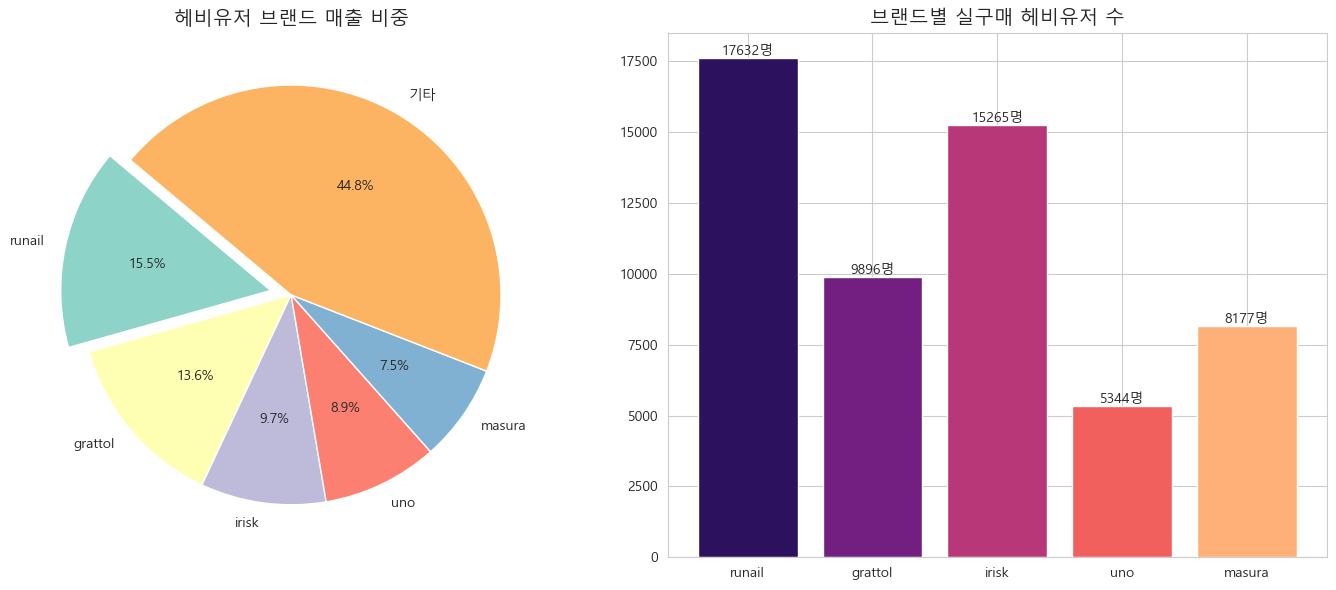

In [16]:
# 헤비유저 구매 로그
heavy_purchase = df[(df['event_type'] == 'purchase') & (df['user_id'].isin(heavy_users))].copy()
heavy_total = heavy_purchase['price'].sum()

# 브랜드별 매출·구매자
brand_rev = heavy_purchase.groupby('brand')['price'].sum()
brand_users = heavy_purchase.groupby('brand')['user_id'].nunique()

heavy_brand = pd.DataFrame({
    'revenue': brand_rev,
    'customers': brand_users
}).sort_values('revenue', ascending=False).head(5)
heavy_brand['share'] = (heavy_brand['revenue'] / heavy_total) * 100

# 상위 브랜드 확인
display(heavy_brand)

etc_share = 100 - heavy_brand['share'].sum()
plot_data = pd.concat([heavy_brand[['share']].reset_index(),
                        pd.DataFrame({'brand': ['기타'], 'share': [etc_share]})])

# 브랜드 선호 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.pie(plot_data['share'], labels=plot_data['brand'], autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('Set3'),
        explode=[0.1 if b == 'runail' else 0 for b in plot_data['brand']])
ax1.set_title('헤비유저 브랜드 매출 비중', fontsize=14)

bars = ax2.bar(heavy_brand.index, heavy_brand['customers'], color=sns.color_palette('magma', 5))
for bar in bars:
    ax2.annotate(f'{int(bar.get_height())}명',
                 (bar.get_x() + bar.get_width()/2, bar.get_height()),
                 ha='center', va='bottom')
ax2.set_title('브랜드별 실구매 헤비유저 수', fontsize=14)
plt.tight_layout()
plt.show()

### 브랜드 비교군과 구매 이탈

장바구니 브랜드 수와 실제 구매 브랜드 수 비교
4개 이상 비교군에서 선택 압축 강함, 구매 전 브랜드 탈락 발생


,user_count,avg_cart_brand,avg_purchase_brand,avg_drop_rate
brand_comp_group,,,,
1~3개,42638,1.80,1.60,5.65
4개+,28487,6.67,4.13,35.41


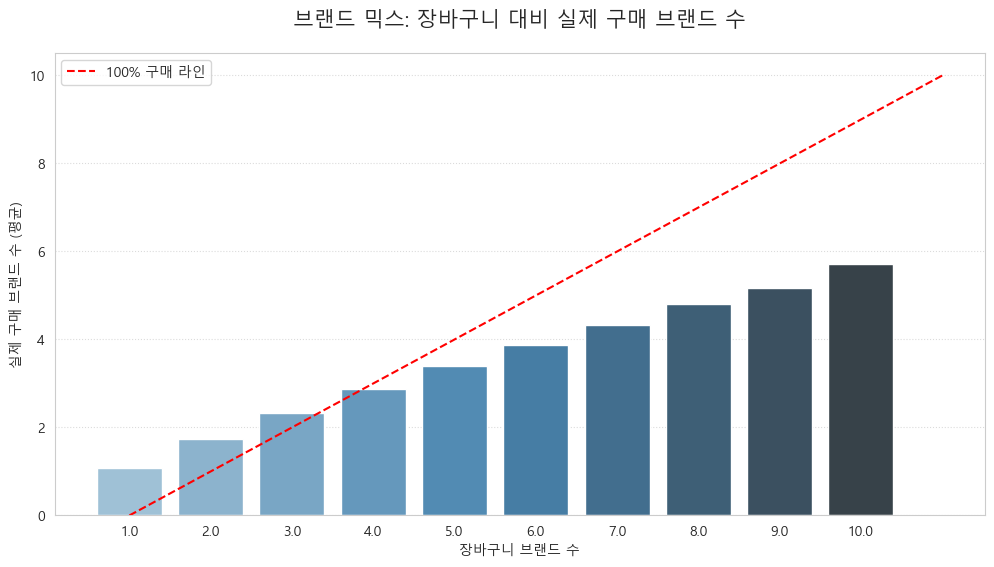

In [17]:
# 장바구니·구매 브랜드 수
cart_brands = df[df['event_type'] == 'cart'].groupby('user_id')['brand'].nunique()
purch_brands = df[df['event_type'] == 'purchase'].groupby('user_id')['brand'].nunique()

# 브랜드 선택 압축률
brand_mix = pd.DataFrame({
    'cart_brand_count': cart_brands,
    'purchase_brand_count': purch_brands
}).dropna()

brand_mix['selection_focus'] = brand_mix['purchase_brand_count'] / brand_mix['cart_brand_count']
brand_mix['compare_drop_rate'] = (1 - brand_mix['selection_focus']) * 100
brand_mix['brand_comp_group'] = np.where(brand_mix['cart_brand_count'] >= 4, '4개+', '1~3개')

# 비교군별 요약
mix_chk = brand_mix.groupby('brand_comp_group').agg(
    user_count=('selection_focus', 'size'),
    avg_cart_brand=('cart_brand_count', 'mean'),
    avg_purchase_brand=('purchase_brand_count', 'mean'),
    avg_drop_rate=('compare_drop_rate', 'mean')
).round(2)
display(mix_chk)

# 장바구니 브랜드 수별 구매 브랜드 수
mix_summary = brand_mix.groupby('cart_brand_count')['purchase_brand_count'].mean().reset_index()

# 브랜드 믹스 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=mix_summary[mix_summary['cart_brand_count'] <= 10],
            x='cart_brand_count', y='purchase_brand_count', palette='Blues_d')
plt.plot([0, 10], [0, 10], color='red', linestyle='--', label='100% 구매 라인')
plt.title('브랜드 믹스: 장바구니 대비 실제 구매 브랜드 수', fontsize=15, pad=20)
plt.xlabel('장바구니 브랜드 수')
plt.ylabel('실제 구매 브랜드 수 (평균)')
plt.legend()
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.show()

## Runail vs Grattol

RUNAIL 유입과 Grattol 이탈 흐름 비교
장바구니 전환 후 실제 구매 매출까지 연결


### 브랜드 전환

Grattol 삭제 후 Runail 담기, Runail 이후 Grattol 담기 흐름 비교
Loss 케이스 우세, 경쟁사 유출 신호 확인


In [18]:
# 장바구니 전환 로그
target = df[df['event_type'].isin(['cart', 'remove_from_cart'])].copy()
target = target.sort_values(['user_id', 'event_time'])
target['prev_brand'] = target.groupby('user_id')['brand'].shift(1)
target['prev_event'] = target.groupby('user_id')['event_type'].shift(1)

# Get 케이스
get_cases = target[
    (target['prev_brand'] == 'grattol') &
    (target['prev_event'] == 'remove_from_cart') &
    (target['brand'] == 'runail') &
    (target['event_type'] == 'cart')
]

# Loss 케이스
loss_cases = target[
    (target['prev_brand'] == 'runail') &
    (target['brand'] == 'grattol') &
    (target['event_type'] == 'cart')
]

print(len(get_cases))
print(len(loss_cases))

3705
12779


### 가격대 차이

Get/Loss 가격 분포 비교
Loss 가격대가 더 높게 형성, 회수 기준 가격대 확인


,Get (Runail Inflow),Loss (Runail Outflow)
count,3705.000000,12779.000000
mean,3.501789,5.500811
std,7.736614,2.323302
min,0.060000,1.900000
25%,0.400000,4.970000
50%,2.250000,5.240000
75%,3.170000,6.030000
max,82.540000,25.240000


8.73
10.32


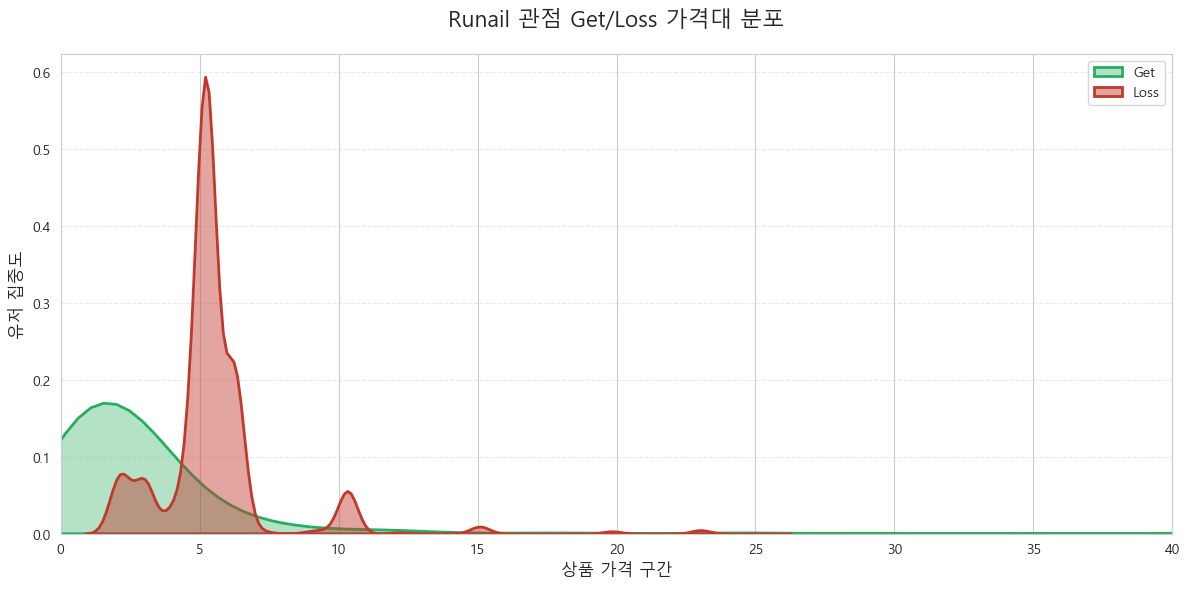

In [19]:
# Get/Loss 가격 통계
get_stats = get_cases['price'].describe()
loss_stats = loss_cases['price'].describe()

price_cmp = pd.DataFrame({
    'Get (Runail Inflow)': get_stats,
    'Loss (Runail Outflow)': loss_stats
})

display(price_cmp)

# 상위 가격 구간
get_95perc = get_cases['price'].quantile(0.95)
loss_95perc = loss_cases['price'].quantile(0.95)
print(get_95perc)
print(loss_95perc)

# 가격대 분포 시각화
plt.figure(figsize=(12, 6))
sns.kdeplot(get_cases['price'], label='Get',
            fill=True, color='#27AE60', alpha=0.35, linewidth=2)
sns.kdeplot(loss_cases['price'], label='Loss',
            fill=True, color='#C0392B', alpha=0.45, linewidth=2)
plt.xlim(0, 40)
plt.title('Runail 관점 Get/Loss 가격대 분포', fontsize=16, pad=20)
plt.xlabel('상품 가격 구간', fontsize=12)
plt.ylabel('유저 집중도', fontsize=12)
plt.legend(loc='upper right', frameon=True)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 구매 전환

Get/Loss 유저의 실제 구매 연결 확인
Loss 유저 구매 매출 규모 우세, 손실 회수 우선순위 상승


In [20]:
# 전체 구매 로그
purchase_all = df[df['event_type'] == 'purchase'].copy()

# Get 구매 전환
get_users = get_cases['user_id'].unique()
get_purchases = purchase_all[
    (purchase_all['user_id'].isin(get_users)) & (purchase_all['brand'] == 'runail')
]
get_cvr = get_purchases['user_id'].nunique() / len(get_users) * 100
get_revenue = get_purchases['price'].sum()

print(len(get_users), get_purchases['user_id'].nunique())
print(get_cvr)
print(get_revenue)

# Loss 구매 전환
loss_users = loss_cases['user_id'].unique()
loss_purchases = purchase_all[
    (purchase_all['user_id'].isin(loss_users)) & (purchase_all['brand'] == 'grattol')
]
loss_cvr = loss_purchases['user_id'].nunique() / len(loss_users) * 100
loss_revenue = loss_purchases['price'].sum()

print(len(loss_users), loss_purchases['user_id'].nunique())
print(loss_cvr)
print(loss_revenue)

print(loss_revenue - get_revenue)

3251 2066
63.54967702245463
30855.27
9871 4473
45.31455779556276
85519.95999999999
54664.68999999999


### 브랜드 전환 요약

Runail 유입과 Grattol 이탈 규모 비교
Loss 이벤트·유저·매출 기여 우세, 순손실 추정 매출 확인


In [21]:
# 전환 유저 수
get_user_count = len(get_users)
loss_user_count = len(loss_users)
get_buyer_count = get_purchases['user_id'].nunique()
loss_buyer_count = loss_purchases['user_id'].nunique()

# Get/Loss 요약
print('전환 시도 건수')
print(len(get_cases), len(loss_cases))

print('전환 고려 유저 수')
print(get_user_count, loss_user_count)

print('최종 구매 유저 수')
print(get_buyer_count, loss_buyer_count)

print('CVR')
print(round(get_cvr, 2), round(loss_cvr, 2))

print('매출')
print(round(get_revenue, 2), round(loss_revenue, 2))

print('순손실')
print(round(loss_revenue - get_revenue, 2))


전환 시도 건수
3705 12779
전환 고려 유저 수
3251 9871
최종 구매 유저 수
2066 4473
CVR
63.55 45.31
매출
30855.27 85519.96
순손실
54664.69


## RFM 군집

RUNAIL 구매 유저 RFM 세분화
핵심군, 최근 유입군, 잠재 이탈군 분리


### RFM 생성

Recency, Frequency, Monetary 분포 확인
RUNAIL 구매 유저 기준 군집 입력값 구성


In [22]:
# 기준일
current_date = df['event_time'].max() + pd.Timedelta(days=1)
runail_purch = df[(df['brand'] == 'runail') & (df['event_type'] == 'purchase')].copy()

# RFM 변수
rfm = pd.DataFrame()
rfm['Recency'] = (current_date - runail_purch.groupby('user_id')['event_time'].max()).dt.days
rfm['Frequency'] = runail_purch.groupby('user_id')['user_id'].count()
rfm['Monetary'] = runail_purch.groupby('user_id')['price'].sum()

print(len(rfm))
display(rfm.describe())

# 로그 변환·스케일링
rfm_log = np.log1p(rfm)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

35411


,Recency,Frequency,Monetary
count,35411.000000,35411.000000,35411.000000
mean,72.393465,3.146141,9.698489
std,43.730274,4.555338,17.949026
min,1.000000,1.000000,0.060000
25%,34.000000,1.000000,1.600000
50%,74.000000,2.000000,4.200000
75%,108.000000,3.000000,9.910000
max,152.000000,126.000000,1065.960000


### K 확인

관성 기울기 완만해지는 지점 K=3 부근
실루엣 K=2(0.3870), K=3(0.3758) 상위, 해석 편의 기준 K=3 유지


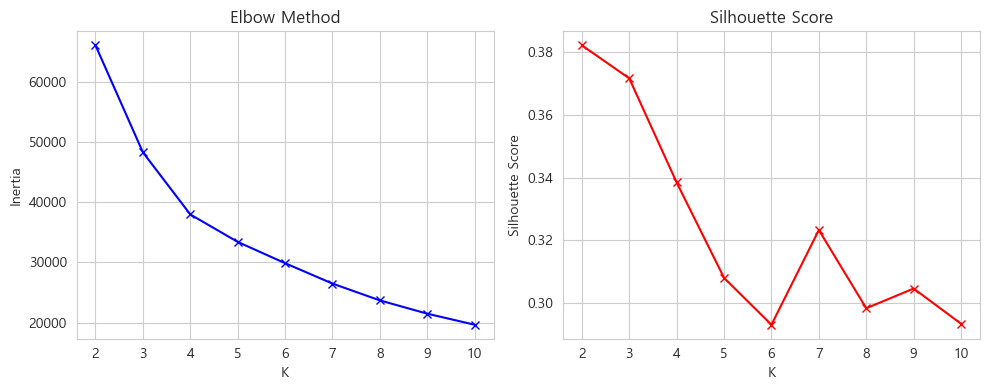

K=2: Silhouette = 0.3823
K=3: Silhouette = 0.3717
K=4: Silhouette = 0.3384
K=5: Silhouette = 0.3079
K=6: Silhouette = 0.2929
K=7: Silhouette = 0.3232
K=8: Silhouette = 0.2982
K=9: Silhouette = 0.3045
K=10: Silhouette = 0.2933


In [23]:
# 군집 기준
seed = 42

# K 후보 평가
X_cluster = rfm_scaled_df
sil_sample = min(3000, len(X_cluster))
k_range = range(2, 11)
inertia, sil_scores = [], []

# K별 학습
for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10,
                random_state=seed)
    km.fit(X_cluster)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster, km.labels_, sample_size=sil_sample, random_state=seed))

# Elbow·Silhouette 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(k_range, inertia, 'bx-')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(k_range, sil_scores, 'rx-')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')
plt.tight_layout()
plt.show()

for k, score in zip(k_range, sil_scores):
    print(f'K={k}: Silhouette = {score:.4f}')

### K=3 군집

군집별 RFM 평균 비교
핵심군과 잠재 이탈군 구분, 회수 전략 대상 분리


,Recency,Frequency,Monetary,Count
Cluster,,,,
1,69.678929,7.270100,25.747442,9378
2,15.878661,2.050364,5.351920,6453
0,92.319254,1.532074,3.444216,19580


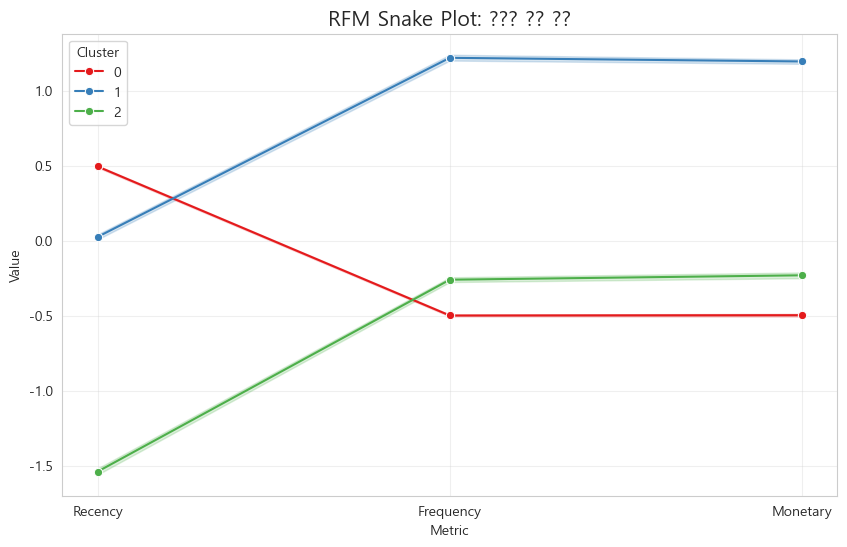

In [24]:
# ?? ?? ?
kmeans_k = 3

# KMeans ??
model = KMeans(n_clusters=kmeans_k, init='k-means++', n_init=10,
               random_state=seed)
raw_cluster = model.fit_predict(rfm_scaled_df)

# ??? ?? ?? ??
cluster_view = {2: 1, 1: 2, 0: 0}
rfm['Cluster'] = pd.Series(raw_cluster, index=rfm.index).map(cluster_view)

# ?? ???
profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
profile['Count'] = rfm['Cluster'].value_counts().sort_index()
profile.index.name = 'Cluster'
profile = profile.loc[[1, 2, 0]]
display(profile)

# Snake Plot ???
X_vis = rfm_scaled_df.copy()
X_vis['Cluster'] = rfm['Cluster']
df_melt = pd.melt(X_vis.reset_index(), id_vars=['user_id', 'Cluster'],
                   value_vars=['Recency', 'Frequency', 'Monetary'],
                   var_name='Metric', value_name='Value')

# ?? ?? ???
plt.figure(figsize=(10, 6))
sns.lineplot(x='Metric', y='Value', hue='Cluster',
             hue_order=[0, 1, 2], data=df_melt, palette='Set1', marker='o')
plt.title('RFM Snake Plot: ??? ?? ??', fontsize=15)
plt.grid(True, alpha=0.3)
plt.show()


## 번들 회수안

Grattol 지출 군집과 회수 가능 매출 확인
$6.5 번들 기준 예상 회수 규모 산출


In [25]:
# 군집 라벨 결합
df_final = df.copy()
df_final['Cluster'] = df_final['user_id'].map(rfm['Cluster'])

# 군집별 브랜드 지출
brand_spend = df_final.groupby(['Cluster', 'brand'])['price'].sum().unstack(fill_value=0)

target_cls = [0, 1]

# 회수 가정
switching_cvr = 0.6355
bundle_price = 6.5

# Grattol 지출 타깃
target = df_final[
    (df_final['Cluster'].isin(target_cls)) &
    (df_final['brand'] == 'grattol')
]

target_users = target['user_id'].nunique()
leaked_revenue = brand_spend.loc[target_cls, 'grattol'].sum()
estimated_gain = (target_users * switching_cvr) * bundle_price

print(leaked_revenue)
print(target_users)
print(estimated_gain)

1197539.1600000001
13098
54104.56349999999


## 대시보드 CSV

Tableau용 누적 파일과 월별 분할 파일 생성
이벤트, 가격구간, 헤비유저, 군집 라벨 포함


In [26]:
# 저장 경로
dash_dir = 'dashboard'
month_dir = os.path.join(dash_dir, 'monthly')
os.makedirs(month_dir, exist_ok=True)

# 대시보드 라벨
cluster_names = {1: '핵심충성군', 2: '최근유입군', 0: '잠재이탈군'}
weekday_kr = {0:'월', 1:'화', 2:'수', 3:'목', 4:'금', 5:'토', 6:'일'}
weekday_en = {0:'Monday', 1:'Tuesday', 2:'Wednesday', 3:'Thursday', 4:'Friday', 5:'Saturday', 6:'Sunday'}

heavy_set = set(heavy_users)
cluster_map = rfm['Cluster'].map(cluster_names).to_dict()

# 가격 구간
price_bins = [0, 2, 5, 10, 20, 50, np.inf]
price_labels = ['$0-2', '$2-5', '$5-10', '$10-20', '$20-50', '$50+']

# 저장 컬럼
cols_dash = [
    'event_time', 'event_type', 'product_id', 'brand', 'price', 'user_id',
    'weekday', 'weekday_name', 'hour', 'weekday_en', 'month', 'date',
    'is_heavy_user', 'price_segment', 'cluster_label',
    'revenue', 'purchase_flag', 'cart_flag', 'view_flag'
]

all_path = os.path.join(dash_dir, 'ecommerce_dashboard_dataset.csv')
done_months = set()
first_part = True

# 월별 CSV 분할 저장
for part in pd.read_csv('nail_market.csv', chunksize=500000):
    part['event_time'] = pd.to_datetime(part['event_time']).dt.tz_localize(None)
    part['weekday'] = part['event_time'].dt.weekday.astype('int8')
    part['weekday_name'] = part['weekday'].map(weekday_kr)
    part['hour'] = part['event_time'].dt.hour.astype('int8')
    part['weekday_en'] = part['weekday'].map(weekday_en)
    part['month'] = part['event_time'].dt.strftime('%Y_%m')
    part['date'] = part['event_time'].dt.strftime('%Y-%m-%d')

    # 대시보드 파생 변수
    part['is_heavy_user'] = part['user_id'].isin(heavy_set).astype('int8')
    part['price_segment'] = pd.cut(part['price'], bins=price_bins, labels=price_labels).astype(str)
    part['cluster_label'] = part['user_id'].map(cluster_map).fillna('미분류')

    part['revenue'] = np.where(part['event_type'].eq('purchase'), part['price'], 0)
    part['purchase_flag'] = part['event_type'].eq('purchase').astype('int8')
    part['cart_flag'] = part['event_type'].eq('cart').astype('int8')
    part['view_flag'] = part['event_type'].eq('view').astype('int8')

    # 누적 파일 저장
    part[cols_dash].to_csv(
        all_path,
        index=False,
        encoding='utf-8-sig',
        mode='w' if first_part else 'a',
        header=first_part
    )
    first_part = False

    # 월별 파일 저장
    for month, month_df in part.groupby('month'):
        out_path = os.path.join(month_dir, f'{month}.csv')
        mode = 'a' if month in done_months else 'w'
        header = month not in done_months
        month_df[cols_dash].to_csv(out_path, index=False, encoding='utf-8-sig', mode=mode, header=header)
        done_months.add(month)

# 저장 결과 확인
pd.Series({
    'rows': sum(1 for _ in open(all_path, encoding='utf-8-sig')) - 1,
    'cols': len(cols_dash),
    'months': len(done_months)
})

rows      7600542
cols           19
months          6
dtype: int64